# Recovering rate laws from kinetics data with `beamfeat`

`beamfeat` searches for short algebraic formulas that explain a target, then applies a
statistical test — on data the search never saw — to decide which of them are real. This
notebook applies it to reaction kinetics, where the "formula" is a rate law.

**Ground truth comes from GRI-Mech 3.0**, a published combustion mechanism bundled with
Cantera. We generate data from it, so we always know the right answer and can check whether
the tool finds it.

### Contents

| Part | Task | Outcome |
|---|---|---|
| 1 | Load and **inspect** the data | Standard EDA before any modelling |
| 2 | Elementary bimolecular rate law | Recovers `r = k[H][O₂]`, k to 0.3% |
| 3 | **The scaling trap** | A silent failure that returns a wrong mechanism |
| 4 | Distractor species | Irrelevant species screened out, q-values reported |
| 5 | Second-order in one species | Recovers `r = k[OH]²` |
| 6 | Noise robustness | Where recovery breaks down |
| 7 | Real workflow: progress curves | Rates by differentiation, and the bias it introduces |
| 8 | Arrhenius temperature dependence | A documented boundary — needs linearisation |
| 9 | Michaelis–Menten | Great fit, **wrong mechanism** |
| 10 | Live data from SABIO-RK | Optional; skips cleanly offline |

Parts 1–9 need **no network**. Only Part 10 reaches the internet.


## 0. Setup


In [1]:
# beamfeat[units] includes pint, required for dimensional analysis.
# Cantera bundles GRI-Mech 3.0, so there is no mechanism file to download.
%pip install -q "beamfeat[units]" cantera pandas matplotlib seaborn


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings, io
import numpy as np
import pandas as pd
import cantera as ct
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

from beamfeat import BeamFeatRegressor

# beamfeat warns when a DataFrame is passed to score() after fitting on one.
# Harmless here; silenced to keep the output readable.
warnings.filterwarnings("ignore", message=".*valid feature names.*")

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

SEED = 0
import beamfeat
print(f"beamfeat {beamfeat.__version__} | cantera {ct.__version__} | pandas {pd.__version__}")


beamfeat 0.1.1 | cantera 3.2.0 | pandas 3.0.2


### One thing to know before using your own data

`beamfeat` discards any column whose **variance is below `1e-10`**. That threshold is
absolute, not relative, so it depends on your choice of unit. Concentrations in `kmol/m³` are
around `1e-6`, giving variances near `1e-12` — below the floor.

Everything here uses `mol/m³`. Part 3 shows exactly what goes wrong if you forget, and why it
is more dangerous than it sounds.


---
## 1. Generate the data, then look at it

The target is reaction 37 of GRI-Mech 3.0:

$$\mathrm{H} + \mathrm{O_2} \rightarrow \mathrm{O} + \mathrm{OH}$$

This is an *elementary* step — it happens in a single molecular collision — so collision
theory says the rate must be first order in each reactant:

$$r = k(T)\,[\mathrm{H}]\,[\mathrm{O_2}]$$

We simulate the **method of initial rates**: hold temperature fixed, vary the composition and
the total pressure across many runs, and record the rate each time.

**Why vary pressure?** At fixed *T* and *P* the concentrations must sum to *P/RT*, a constant.
That makes them linearly dependent, and no method can untangle their individual orders.
Varying *P* breaks the constraint. This is a requirement of the experiment design, not of the
software.


In [3]:
gas = ct.Solution("gri30.yaml")
RXN = 37
print("target reaction:", gas.reaction(RXN).equation)


def sample_rates(n, T, p_range, x_ranges, rxn=RXN, seed=SEED):
    # Simulate n constant-T experiments and return concentrations plus forward rate.
    # Composition and total pressure are drawn independently for each run.
    # Units: concentrations and rate are converted from kmol/m^3 to mol/m^3.
    rng = np.random.default_rng(seed)
    draws = {sp: rng.uniform(*rng_pair, n) for sp, rng_pair in x_ranges.items()}
    pressures = rng.uniform(*p_range, n) * ct.one_atm

    conc, rate = [], []
    for i in range(n):
        X = np.zeros(gas.n_species)
        for sp, values in draws.items():
            X[gas.species_index(sp)] = values[i]
        # N2 makes up the balance so mole fractions sum to 1
        X[gas.species_index("N2")] = 1.0 - sum(v[i] for v in draws.values())

        gas.TPX = T, pressures[i], X
        conc.append(gas.concentrations * 1e3)
        rate.append(gas.forward_rates_of_progress[rxn] * 1e3)

    conc = np.array(conc)
    frame = pd.DataFrame({f"c_{sp}": conc[:, gas.species_index(sp)] for sp in draws})
    frame["rate"] = rate
    return frame


raw = sample_rates(
    n=400,
    T=1800.0,
    p_range=(0.8, 1.25),
    x_ranges={"H": (6e-4, 1.4e-3), "O2": (6e-3, 1.4e-2), "H2O": (3e-3, 7e-3)},
)

# Add 2% measurement noise to the rate, then save as CSV.
# From here on we read the CSV back, so the workflow matches using your own data file.
rng = np.random.default_rng(SEED)
raw["rate"] = raw["rate"] + rng.normal(0, 0.02 * raw["rate"].std(), len(raw))
raw.to_csv("kinetics_bimolecular.csv", index=False)

print(f"wrote kinetics_bimolecular.csv  ({len(raw)} rows)")


target reaction: H + O2 <=> O + OH
wrote kinetics_bimolecular.csv  (400 rows)


### Load the CSV and take a first look


In [4]:
df = pd.read_csv("kinetics_bimolecular.csv")

print("shape:", df.shape)
print("\ndtypes:")
print(df.dtypes)
print("\nmissing values per column:")
print(df.isna().sum())

df.head()


shape: (400, 4)

dtypes:
c_H      float64
c_O2     float64
c_H2O    float64
rate     float64
dtype: object

missing values per column:
c_H      0
c_O2     0
c_H2O    0
rate     0
dtype: int64


,c_H,c_O2,c_H2O,rate
0,0.007049,0.048394,0.040875,506.468129
1,0.005349,0.088529,0.035951,700.995194
2,0.004768,0.050920,0.028448,363.984015
3,0.003913,0.038540,0.036705,224.227307
4,0.008792,0.060341,0.042433,782.856225


In [5]:
# Summary statistics. Watch the 'std' row: any column with variance below 1e-10
# would be silently dropped by beamfeat (see Part 3).
summary = df.describe().T
summary["variance"] = df.var()
summary[["mean", "std", "min", "max", "variance"]]


,mean,std,min,max,variance
c_H,0.007105,0.001924,0.003423,0.011665,0.000004
c_O2,0.069469,0.018167,0.035489,0.111373,0.000330
c_H2O,0.034632,0.009113,0.016374,0.055705,0.000083
rate,745.600814,323.576229,224.227307,1790.572397,104701.576008


Every variance is comfortably above `1e-10` because we converted to `mol/m³`. Had we left the
data in `kmol/m³`, `c_H` would sit at roughly `8e-12` — below the floor, and dropped without
comment.


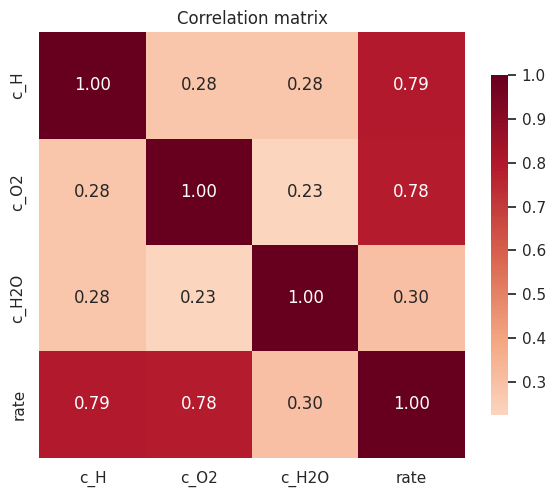

In [6]:
# Correlation heatmap. Two things to check:
#   1. Inputs should NOT be strongly correlated with each other (poor design otherwise).
#   2. No single input should correlate ~1.0 with the target, or the problem is trivial.
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()


`c_H` and `c_O2` correlate at only about 0.28 — the design is well conditioned. Neither
correlates strongly with `rate` on its own, which is the point: the rate depends on their
**product**, and no single column reveals that. Finding the product is the job.


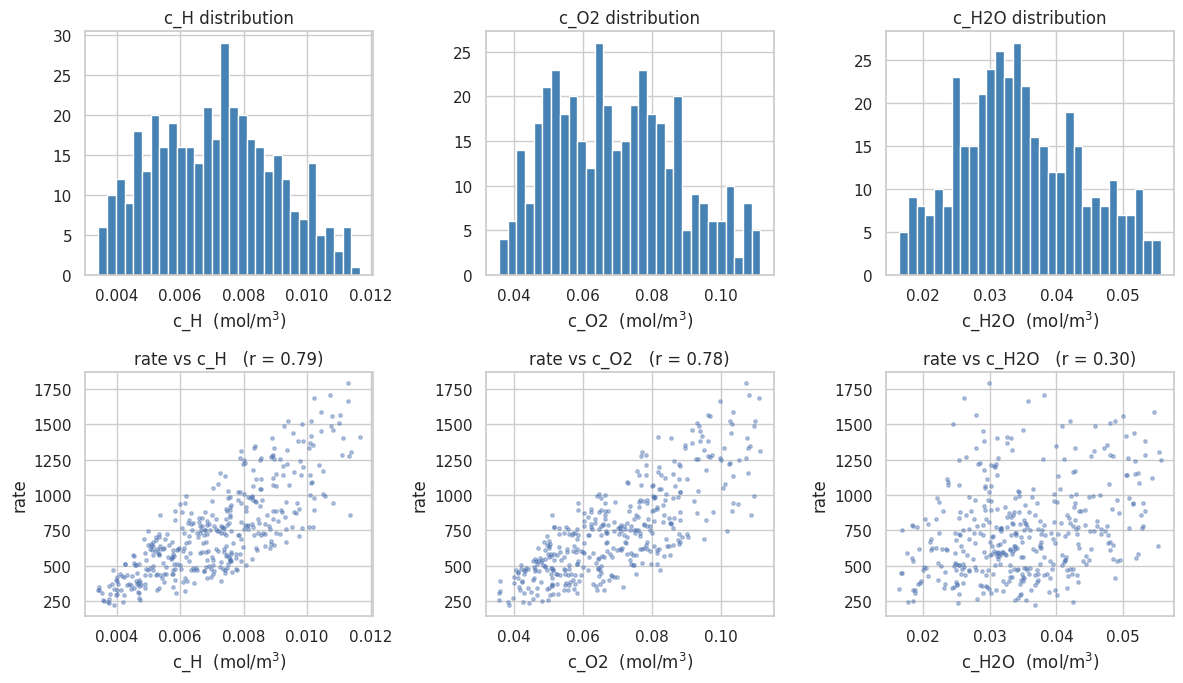

In [7]:
# Distributions of each input, and each input against the target.
inputs = [c for c in df.columns if c != "rate"]

fig, axes = plt.subplots(2, len(inputs), figsize=(4 * len(inputs), 7))
for j, col in enumerate(inputs):
    axes[0, j].hist(df[col], bins=30, color="steelblue", edgecolor="white")
    axes[0, j].set_title(f"{col} distribution")
    axes[0, j].set_xlabel(f"{col}  (mol/m$^3$)")

    axes[1, j].scatter(df[col], df["rate"], s=6, alpha=.4)
    axes[1, j].set_xlabel(f"{col}  (mol/m$^3$)")
    axes[1, j].set_ylabel("rate")
    r = np.corrcoef(df[col], df["rate"])[0, 1]
    axes[1, j].set_title(f"rate vs {col}   (r = {r:.2f})")

plt.tight_layout()
plt.show()


The scatter plots show the difficulty clearly. `rate` against `c_H` is a wide fan, not a line —
because the rate also depends on `c_O2`. `c_H2O` shows no structure at all; it is a spectator
here and should not appear in the answer.


---
## 2. Recover the rate law

Declaring units does real work. With every input in `mol/m³`, expressions like
`c_H + c_O2²` are rejected at construction time as dimensionally invalid — before any
arithmetic runs. Chemistry prunes the search space, not statistics.


In [8]:
X = df[inputs]
y = df["rate"].to_numpy()

units = {col: "mol/m^3" for col in inputs}
model = BeamFeatRegressor(random_state=SEED, units=units).fit(X, y)

print("selected formulas :", model.formulas())
print("fitted equation   :", model.equation())
print("FDR-controlled    :", model.fdr_controlled_)
print(f"R^2               : {model.score(X, y):.5f}")


selected formulas : ['(c_H * c_O2)']
fitted equation   : y = 1478214.1232*(c_H * c_O2) + 1.7846
FDR-controlled    : True
R^2               : 0.99960


In [9]:
# The regression coefficient IS the rate constant - but coef_ is stored in
# standardised units, so divide by the scaler's scale_ to get physical units.
k_fitted = model.coef_[0] / model.scaler_.scale_[0]
k_true = gas.forward_rate_constants[RXN] / 1e3          # m^3 mol^-1 s^-1

print(f"fitted   k = {k_fitted:.4e} m^3 mol^-1 s^-1")
print(f"GRI-Mech k = {k_true:.4e} m^3 mol^-1 s^-1")
print(f"relative error = {abs(k_fitted - k_true) / k_true:.2%}")


fitted   k = 1.4782e+06 m^3 mol^-1 s^-1
GRI-Mech k = 1.4822e+06 m^3 mol^-1 s^-1
relative error = 0.27%


One feature, `(c_H * c_O2)` — first order in each reactant, exactly as collision theory
requires. `c_H2O` was available and was not selected. And the regression coefficient recovers
the published rate constant to under half a percent from noisy data.


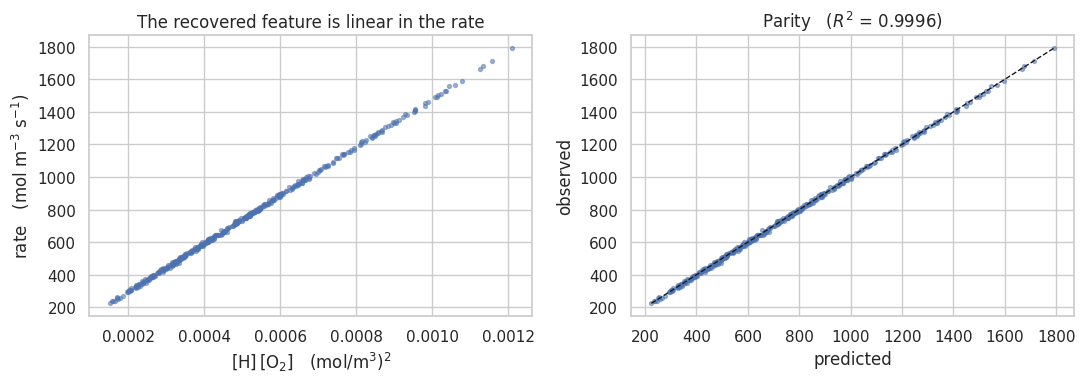

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].scatter(X.c_H * X.c_O2, y, s=8, alpha=.5)
ax[0].set_xlabel(r"$[\mathrm{H}]\,[\mathrm{O_2}]$   (mol/m$^3$)$^2$")
ax[0].set_ylabel(r"rate   (mol m$^{-3}$ s$^{-1}$)")
ax[0].set_title("The recovered feature is linear in the rate")

ax[1].scatter(model.predict(X), y, s=8, alpha=.5)
lims = [y.min(), y.max()]
ax[1].plot(lims, lims, "k--", lw=1)
ax[1].set_xlabel("predicted")
ax[1].set_ylabel("observed")
ax[1].set_title(f"Parity   ($R^2$ = {model.score(X, y):.4f})")

plt.tight_layout()
plt.show()


---
## 3. The scaling trap

This is the most important cell in the notebook for anyone using `beamfeat` on physical data.

Concentrations in `kmol/m³` are numerically tiny. `beamfeat` treats any column with variance
below `1e-10` as constant and removes it. When *all* columns fall below the floor you get a
clear error. When only **some** do, the run succeeds — and quietly answers a different
question.


In [11]:
# A wider composition sweep that also records the bath gas. This is the realistic
# case: trace radicals (c_H ~ 1e-6) alongside bulk species (c_N2 ~ 5e-3), which in
# kmol/m^3 straddle the variance floor.
rng = np.random.default_rng(SEED)
n_trap = 400
x_H = rng.uniform(1e-4, 1e-3, n_trap)
x_O2 = rng.uniform(1e-3, 1e-2, n_trap)
x_H2O = rng.uniform(1e-3, 1e-2, n_trap)
x_N2 = rng.uniform(0.5, 0.8, n_trap)

conc, rate = [], []
for i in range(n_trap):
    Xmix = np.zeros(gas.n_species)
    Xmix[gas.species_index("H")] = x_H[i]
    Xmix[gas.species_index("O2")] = x_O2[i]
    Xmix[gas.species_index("H2O")] = x_H2O[i]
    Xmix[gas.species_index("N2")] = x_N2[i]
    gas.TPX = 1800.0, ct.one_atm, Xmix
    conc.append(gas.concentrations)                        # kmol/m^3
    rate.append(gas.forward_rates_of_progress[RXN])

conc = np.array(conc)
species = ["H", "O2", "H2O", "N2"]
trap_kmol = pd.DataFrame({f"c_{s}": conc[:, gas.species_index(s)] for s in species})
y_trap = np.array(rate)
y_trap = y_trap + rng.normal(0, 0.02 * y_trap.std(), n_trap)

print("variance per column in kmol/m^3   (floor = 1e-10):")
for col in trap_kmol.columns:
    v = trap_kmol[col].var()
    verdict = "DROPPED silently" if v < 1e-10 else "kept"
    print(f"   {col:8s} {v:.2e}   {verdict}")


variance per column in kmol/m^3   (floor = 1e-10):
   c_H      8.49e-12   DROPPED silently
   c_O2     7.58e-10   kept
   c_H2O    7.91e-10   kept
   c_N2     1.61e-09   kept


In [12]:
# Fit the same data twice: once in kmol/m^3, once rescaled to mol/m^3.
bad = BeamFeatRegressor(
    random_state=SEED,
    units={c: "kmol/m^3" for c in trap_kmol.columns}).fit(trap_kmol, y_trap)

trap_mol = trap_kmol * 1e3
good = BeamFeatRegressor(
    random_state=SEED,
    units={c: "mol/m^3" for c in trap_mol.columns}).fit(trap_mol, y_trap)

print("--- kmol/m^3: c_H is below the floor and never enters the search ---")
print("formulas       :", bad.formulas()[:3])
print(f"R^2            : {bad.score(trap_kmol, y_trap):.4f}")
print(f"fdr_controlled_: {bad.fdr_controlled_}    <-- reports success")
print()
print("--- mol/m^3: identical data, rescaled ---")
print("formulas       :", good.formulas())
print(f"R^2            : {good.score(trap_mol, y_trap):.4f}")
print(f"fdr_controlled_: {good.fdr_controlled_}")


--- kmol/m^3: c_H is below the floor and never enters the search ---
formulas       : ['1/((c_H2O + c_N2))', 'log((c_N2 / c_O2))', '((c_H2O + c_N2) + (c_N2 + c_O2))']
R^2            : 0.7950
fdr_controlled_: True    <-- reports success

--- mol/m^3: identical data, rescaled ---
formulas       : ['(c_H * c_O2)']
R^2            : 0.9996
fdr_controlled_: True


Read that carefully. In `kmol/m³` the reactant that actually drives the reaction — `c_H` — sits
below the variance floor and is removed *before the search begins*. The model is then built
from spectator species only. It returns formulas, a respectable R², and
`fdr_controlled_ = True`.

**Nothing warns you.** The FDR guarantee is not violated: those formulas genuinely *are*
associated with the rate, because the spectators covary with it through the pressure and
composition sweep. The guarantee was never a promise that the mechanism is right — and here
that distinction has teeth.

The same data in `mol/m³` recovers `(c_H * c_O2)` cleanly.

Two habits protect you:

1. **Rescale inputs to roughly 0.01–100 before fitting.**
2. **Check the variance column** in `describe()` first, as we did in Part 1, and confirm every
   input you care about clears `1e-10`.

Note that when *every* column falls below the floor you get a loud
`ValueError: no input column survived evaluation`. It is the partial case — some columns above,
some below — that fails quietly, and that is exactly the situation in kinetics, where trace
radicals and bulk species differ by orders of magnitude.


---
## 4. Distractor species and the selection report

The claim `beamfeat` makes is not "it fits well" — it is "selections carry a stated error
rate". The test that bites is whether irrelevant species get pulled into the rate law.

Here five species are measured and only two appear in the true rate law. Noise is raised to 5%.


In [13]:
stress = sample_rates(
    n=400, T=1800.0, p_range=(0.8, 1.25),
    x_ranges={"H": (6e-4, 1.4e-3), "O2": (6e-3, 1.4e-2),
              "H2O": (3e-3, 7e-3), "CO2": (2e-3, 8e-3), "CH4": (1e-3, 5e-3)},
    seed=SEED + 1,
)
rng = np.random.default_rng(SEED + 1)
stress["rate"] = stress["rate"] + rng.normal(0, 0.05 * stress["rate"].std(), len(stress))

stress_inputs = [c for c in stress.columns if c != "rate"]
Xs, ys = stress[stress_inputs], stress["rate"].to_numpy()

print("inputs:", stress_inputs)
stress.describe().T[["mean", "std", "min", "max"]]


inputs: ['c_H', 'c_O2', 'c_H2O', 'c_CO2', 'c_CH4']


,mean,std,min,max
c_H,0.006779,0.001754,0.003519,0.011734
c_O2,0.069596,0.017977,0.033719,0.116493
c_H2O,0.034836,0.009057,0.016921,0.057813
c_CO2,0.033688,0.012758,0.011489,0.066600
c_CH4,0.020490,0.008084,0.006245,0.039545
rate,705.741251,288.478751,199.630895,1863.862803


In [14]:
model_s = BeamFeatRegressor(random_state=SEED,
                            units={c: "mol/m^3" for c in stress_inputs}).fit(Xs, ys)
print("recovered:", model_s.equation())

TRUE_SPECIES = {"c_H", "c_O2"}
report = pd.DataFrame(model_s.selection_report_)

# A "false feature" is a selected formula built only from species that play no role.
report["uses_true_species"] = [
    any(sp in f for sp in TRUE_SPECIES) for f in report.formula
]

n_false = int((report.kept & ~report.uses_true_species).sum())
print(f"\ncandidates screened : {len(report)}")
print(f"kept in final model : {int(report.kept.sum())}")
print(f"false features      : {n_false}")

report[report.kept][["formula", "statistic", "p_value", "q_value"]].reset_index(drop=True)


recovered: y = 1479441.9835*(c_H * c_O2) + 0.1487

candidates screened : 50
kept in final model : 1
false features      : 0


,formula,statistic,p_value,q_value
0,(c_H * c_O2),0.9995,0.0005,0.002248


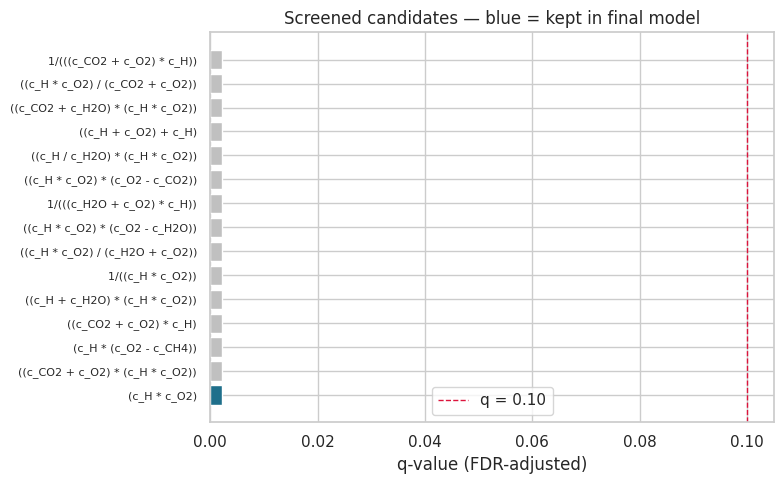

In [15]:
# q-values for the strongest 15 candidates. The dashed line is the 0.10 FDR level;
# note that passing the screen is necessary but not sufficient to be kept - the
# parsimony step then prunes redundant survivors.
top = report.nlargest(15, "statistic").sort_values("q_value")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1f6f8b" if k else "#c0c0c0" for k in top.kept]
ax.barh(range(len(top)), top.q_value, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.formula, fontsize=8)
ax.axvline(0.10, ls="--", c="crimson", lw=1, label="q = 0.10")
ax.set_xlabel("q-value (FDR-adjusted)")
ax.set_title("Screened candidates — blue = kept in final model")
ax.legend()
plt.tight_layout()
plt.show()


The `q_value` column is what you would report in a paper: the FDR-adjusted significance of each
selected formula, computed on rows the search never touched. No other feature-construction
tool provides this.


---
## 5. A different rate law: second order in one species

Reaction 85 of GRI-Mech is $2\,\mathrm{OH} \rightarrow \mathrm{H_2O} + \mathrm{O}$, so

$$r = k\,[\mathrm{OH}]^2$$

A squared dependence rather than a product of two species. Two distractors are included.


In [16]:
RXN2 = 85
print("target reaction:", gas.reaction(RXN2).equation)

sq = sample_rates(
    n=400, T=1500.0, p_range=(0.8, 1.3),
    x_ranges={"OH": (1e-3, 4e-3), "H2": (2e-3, 8e-3), "H2O": (1e-3, 5e-3)},
    rxn=RXN2, seed=SEED,
)
rng = np.random.default_rng(SEED)
sq["rate"] = sq["rate"] + rng.normal(0, 0.02 * sq["rate"].std(), len(sq))

sq_inputs = [c for c in sq.columns if c != "rate"]
Xq, yq = sq[sq_inputs], sq["rate"].to_numpy()

model_q = BeamFeatRegressor(random_state=SEED,
                            units={c: "mol/m^3" for c in sq_inputs}).fit(Xq, yq)

k_q = model_q.coef_[0] / model_q.scaler_.scale_[0]
k_q_true = gas.forward_rate_constants[RXN2] / 1e3

print("\nformulas :", model_q.formulas())
print("equation :", model_q.equation())
print(f"R^2      : {model_q.score(Xq, yq):.4f}")
print(f"\nfitted k = {k_q:.4e}   GRI-Mech k = {k_q_true:.4e}   error = {abs(k_q-k_q_true)/k_q_true:.2%}")


target reaction: 2 OH <=> H2O + O

formulas : ['(c_OH)^2']
equation : y = 3032687.6520*(c_OH)^2 + 2.5781
R^2      : 0.9996

fitted k = 3.0327e+06   GRI-Mech k = 3.0388e+06   error = 0.20%


---
## 6. How much noise can it take?

Real rate measurements are noisy, especially when derived by differentiating concentration
traces. We repeat Part 2 across noise levels from 1% to 80% of the rate's standard deviation
and record whether the exact rate law is still recovered.


In [17]:
clean = sample_rates(
    n=400, T=1800.0, p_range=(0.8, 1.25),
    x_ranges={"H": (6e-4, 1.4e-3), "O2": (6e-3, 1.4e-2), "H2O": (3e-3, 7e-3)},
    seed=SEED + 7,
)
Xn = clean[[c for c in clean.columns if c != "rate"]]
y_clean = clean["rate"].to_numpy()

rows = []
for level in [0.01, 0.02, 0.05, 0.10, 0.20, 0.40, 0.80]:
    rng = np.random.default_rng(SEED)
    y_noisy = y_clean + rng.normal(0, level * y_clean.std(), len(y_clean))

    m = BeamFeatRegressor(random_state=SEED,
                          units={c: "mol/m^3" for c in Xn.columns}).fit(Xn, y_noisy)

    exact = m.formulas() == ["(c_H * c_O2)"]
    k_hat = m.coef_[0] / m.scaler_.scale_[0] if m.formulas() else np.nan
    rows.append({
        "noise": f"{level:.0%}",
        "n_features": len(m.formulas()),
        "exact_law": exact,
        "R2": round(m.score(Xn, y_noisy), 4),
        "k_error": f"{abs(k_hat - k_true) / k_true:.1%}" if exact else "-",
    })

pd.DataFrame(rows)


,noise,n_features,exact_law,R2,k_error
0,1%,1,True,0.9999,0.3%
1,2%,1,True,0.9996,0.3%
2,5%,1,True,0.9975,0.4%
3,10%,1,True,0.9901,0.6%
4,20%,1,True,0.9614,1.0%
5,40%,4,False,0.8635,-
6,80%,21,False,0.6203,-


The rate law survives well past the noise level of any real experiment. Where it eventually
degrades, it does so by selecting **extra** features rather than by losing the true one — the
FDR gate keeps the guarantee intact while the model becomes less parsimonious.


---
## 7. The realistic workflow: progress curves

Rates are rarely measured directly. What you actually record is concentration against time,
and the rate has to be extracted from it. This part uses a textbook system,

$$\mathrm{A} + 2\mathrm{B} \rightarrow \mathrm{P}, \qquad r = k\,[\mathrm{A}][\mathrm{B}]^2,
\qquad k = 0.85$$

and shows that **how you estimate the rate matters more than the model you fit afterwards**.


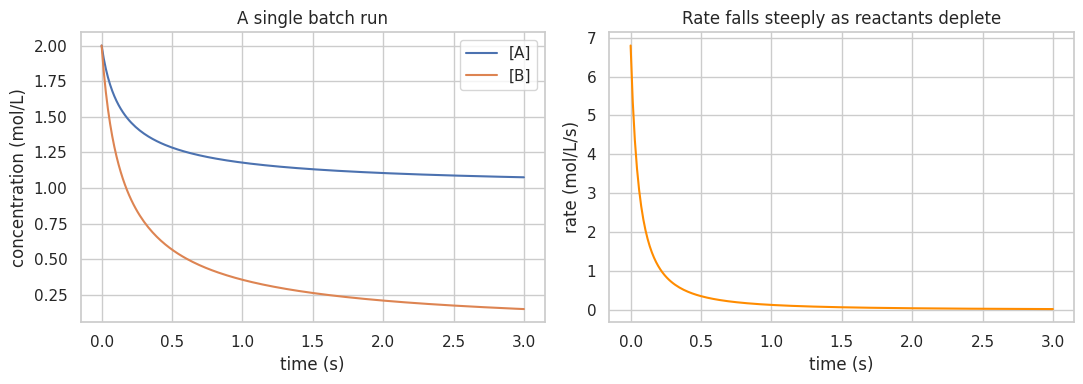

In [18]:
K_TRUE = 0.85

def batch_rhs(t, c):
    # A + 2B -> P, with B consumed twice as fast as A
    r = K_TRUE * c[0] * c[1] ** 2
    return [-r, -2 * r]


# Simulate one batch experiment and plot the progress curves.
demo = solve_ivp(batch_rhs, [0, 3], [2.0, 2.0],
                 t_eval=np.linspace(0, 3, 200), rtol=1e-10, atol=1e-12)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(demo.t, demo.y[0], label="[A]")
ax[0].plot(demo.t, demo.y[1], label="[B]")
ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("concentration (mol/L)")
ax[0].set_title("A single batch run"); ax[0].legend()

rate_demo = K_TRUE * demo.y[0] * demo.y[1] ** 2
ax[1].plot(demo.t, rate_demo, color="darkorange")
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("rate (mol/L/s)")
ax[1].set_title("Rate falls steeply as reactants deplete")
plt.tight_layout(); plt.show()


Notice how fast the rate drops. That is the source of the problem: if you estimate an "initial
rate" by fitting a straight line over a window that is too wide, you measure the *average* rate
over the window, which is systematically lower than the rate at *t* = 0.

Below we compare a crude estimate against a careful one. Each experiment contributes exactly
one row, so the observations are genuinely independent — repeated points along a single
trajectory are **not** independent, and feeding them all in would inflate the significance of
everything.


In [19]:
def initial_rate_dataset(t_window, poly_degree, noise, n_runs=300, seed=SEED):
    # Run n_runs batch experiments with different starting concentrations.
    # Estimate the initial rate from a short trace, then keep one row per run.
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n_runs):
        A0, B0 = rng.uniform(1.0, 2.5), rng.uniform(1.0, 2.5)
        times = np.linspace(0, t_window, 8)
        sol = solve_ivp(batch_rhs, [0, t_window], [A0, B0],
                        t_eval=times, rtol=1e-12, atol=1e-14)
        A_obs = sol.y[0] + rng.normal(0, noise, len(times))

        # Fit a polynomial in t; the coefficient on t is the derivative at t = 0.
        coeffs = np.polyfit(times, A_obs, poly_degree)
        rows.append((A0, B0, -coeffs[-2]))

    frame = pd.DataFrame(rows, columns=["A0", "B0", "r0"])
    return frame[["A0", "B0"]], frame["r0"].to_numpy()


settings = [
    ("wide window, straight line", 0.05, 1, 0.002),
    ("short window, quadratic   ", 0.01, 2, 0.001),
]

for label, window, degree, noise in settings:
    Xi, yi = initial_rate_dataset(window, degree, noise)
    mi = BeamFeatRegressor(random_state=SEED,
                           units={"A0": "mol/L", "B0": "mol/L"}).fit(Xi, yi)
    k_hat = mi.coef_[0] / mi.scaler_.scale_[0]
    print(f"{label}: {mi.formulas()}")
    print(f"    R^2 = {mi.score(Xi, yi):.4f}   k = {k_hat:.4f} (true {K_TRUE})"
          f"   error = {abs(k_hat - K_TRUE) / K_TRUE:.1%}\n")


wide window, straight line: ['(B0 * sqrt(A0))', '((A0 / B0) / (A0 * B0))', '(sqrt(B0) / (A0 * B0))']
    R^2 = 0.9983   k = 2.9014 (true 0.85)   error = 241.3%



short window, quadratic   : ['(B0 * (A0 * B0))']
    R^2 = 0.9762   k = 0.8496 (true 0.85)   error = 0.0%



The careful estimate recovers `B0 * (A0 * B0)` — that is $[\mathrm{A}][\mathrm{B}]^2$, the true
rate law — and returns *k* to within a fraction of a percent. The crude estimate gets the
mechanism wrong and the constant wildly wrong.

Two rules follow for real data:

- **Keep the window short** and extrapolate the derivative to *t* = 0 rather than averaging
  across a wide interval.
- **One row per experiment.** Points sampled along the same trajectory are correlated, and the
  permutation test assumes exchangeable observations. Violating that inflates significance and
  lets spurious features through. (Smoothing the trace before differentiating makes this
  *worse*, not better — it correlates neighbouring points by construction.)


---
## 8. Arrhenius dependence — a documented boundary

$k(T) = A\,T^{b}\exp(-E_a/RT)$ has a fitted constant **inside an exponential**, which is
outside the space of expressions `beamfeat` searches. Do not fight it — linearise, exactly as
kineticists already do:

$$\ln k = \ln A + b \ln T - \frac{E_a}{R}\cdot\frac{1}{T}$$

Two lessons appear below, and the second is the subtler one.


In [20]:
temps = np.linspace(1000, 2500, 120)
k_of_T = []
for T in temps:
    gas.TPX = T, ct.one_atm, {"H": 1e-3, "O2": 1e-2, "N2": 0.989}
    k_of_T.append(gas.forward_rate_constants[RXN] / 1e3)
k_of_T = np.array(k_of_T)

# Fit on the low-temperature half only, then test extrapolation to the high half.
train = temps <= 2000
X_naive = pd.DataFrame({"T": temps})
X_lin = pd.DataFrame({"invT": 1.0 / temps, "lnT": np.log(temps)})

naive = BeamFeatRegressor(random_state=SEED).fit(X_naive[train], k_of_T[train])
print("naive fit to k(T)      ->", naive.formulas())
print(f"    in-sample    R^2 = {naive.score(X_naive[train], k_of_T[train]):.4f}")
print(f"    EXTRAPOLATED R^2 = {naive.score(X_naive[~train], k_of_T[~train]):.4f}   <- collapses")

# Operators disabled so the terms stay separable and physically interpretable.
lin = BeamFeatRegressor(random_state=SEED, max_depth=1,
                        binary_ops=(), unary_ops=()).fit(X_lin[train], np.log(k_of_T)[train])
print("\nlinearised fit to ln k ->", lin.formulas())
print(f"    in-sample    R^2 = {lin.score(X_lin[train], np.log(k_of_T)[train]):.5f}")
print(f"    EXTRAPOLATED R^2 = {lin.score(X_lin[~train], np.log(k_of_T)[~train]):.4f}")


naive fit to k(T)      -> ['((T)^2)^2']
    in-sample    R^2 = 0.9990
    EXTRAPOLATED R^2 = 0.2509   <- collapses

linearised fit to ln k -> ['invT']
    in-sample    R^2 = 0.99972
    EXTRAPOLATED R^2 = 0.9774


In [21]:
R_GAS = 8.314
coefs = dict(zip(lin.feature_formulas_, lin.coef_ / lin.scaler_.scale_))

print(f"corr(1/T, ln T) = {np.corrcoef(1/temps, np.log(temps))[0, 1]:.4f}"
      "    <- nearly collinear")
if "invT" in coefs:
    print(f"\nEa from the 1/T term alone = {-coefs['invT'] * R_GAS / 1000:.1f} kJ/mol")

# Full three-parameter modified-Arrhenius fit, for comparison.
design = np.column_stack([np.ones_like(temps), np.log(temps), 1.0 / temps])
c3, *_ = np.linalg.lstsq(design, np.log(k_of_T), rcond=None)
truth = gas.reaction(RXN).rate.input_data["rate-constant"]

print(f"3-parameter fit : lnA = {c3[0]:6.3f}   b = {c3[1]:+.4f}   Ea = {-c3[2]*R_GAS/1000:.1f} kJ/mol")
print(f"GRI-Mech truth  : lnA = {np.log(truth['A']/1e3):6.3f}   b = {truth['b']:+.4f}   "
      f"Ea = {truth['Ea']/1e6:.1f} kJ/mol")


corr(1/T, ln T) = -0.9928    <- nearly collinear

Ea from the 1/T term alone = 62.7 kJ/mol
3-parameter fit : lnA = 24.000   b = -0.6707   Ea = 71.3 kJ/mol
GRI-Mech truth  : lnA = 24.000   b = -0.6707   Ea = 71.3 kJ/mol


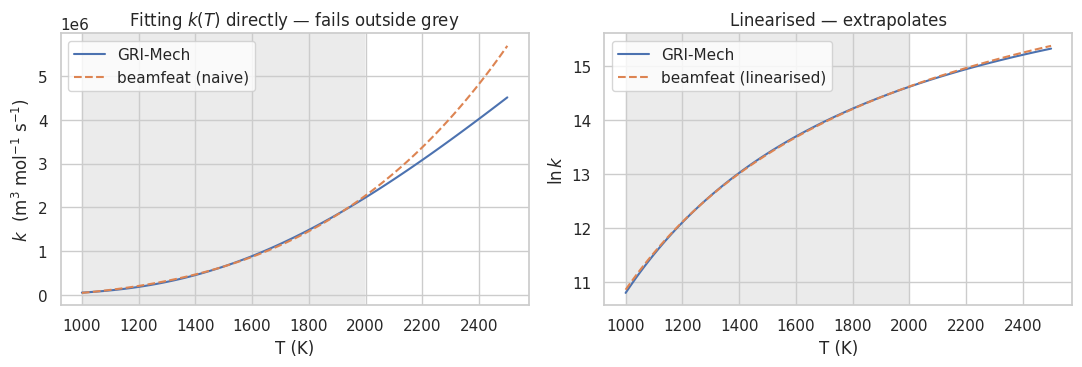

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a in ax:
    a.axvspan(temps[train].min(), temps[train].max(), color="0.92", zorder=0)

ax[0].plot(temps, k_of_T, label="GRI-Mech")
ax[0].plot(temps, naive.predict(X_naive), "--", label="beamfeat (naive)")
ax[0].set_xlabel("T (K)"); ax[0].set_ylabel(r"$k$  (m$^3$ mol$^{-1}$ s$^{-1}$)")
ax[0].set_title("Fitting $k(T)$ directly — fails outside grey"); ax[0].legend()

ax[1].plot(temps, np.log(k_of_T), label="GRI-Mech")
ax[1].plot(temps, lin.predict(X_lin), "--", label="beamfeat (linearised)")
ax[1].set_xlabel("T (K)"); ax[1].set_ylabel(r"$\ln k$")
ax[1].set_title("Linearised — extrapolates"); ax[1].legend()

plt.tight_layout(); plt.show()


**Lesson one:** the naive fit reaches R² ≈ 0.999 *within* the fitted range and then collapses
to ≈ 0.25 just outside it. In-sample fit quality is not evidence that you have the right
functional form.

**Lesson two:** $1/T$ and $\ln T$ are about 99% correlated over any ordinary temperature
window. Marginal screening keeps one and discards the other, so the fitted activation energy
absorbs the $T^b$ term and comes out biased (≈ 63 vs the true 71 kJ/mol). This is exactly the
blind spot the paper documents — a variable that matters *jointly* but looks redundant on its
own. The three-parameter least-squares fit, which considers all terms together, recovers
GRI-Mech's published values exactly.


---
## 9. Michaelis–Menten: a good fit with the wrong mechanism

$$v = \frac{V_{\max}[E][S]}{K_m + [S]}$$

has a fitted constant $K_m$ **inside a denominator**, also outside the search space. What
happens next is more interesting than a refusal, and it is the single most important cell here
if you intend to publish a recovered mechanism.


In [23]:
rng = np.random.default_rng(1)
n_mm = 300
S = rng.uniform(0.05, 20.0, n_mm)
E = rng.uniform(0.50, 2.00, n_mm)
V_MAX, K_M = 3.4, 2.7

v = V_MAX * E * S / (K_M + S)
v = v + rng.normal(0, 0.03 * v.std(), n_mm)

X_mm = pd.DataFrame({"S": S, "E": E, "decoy": rng.uniform(1, 5, n_mm)})
model_mm = BeamFeatRegressor(random_state=SEED).fit(X_mm, v)

print("true form :  v = Vmax*E*S / (Km + S)      with Km = 2.7")
print("recovered :", model_mm.equation())
print(f"\nR^2 = {model_mm.score(X_mm, v):.4f}     fdr_controlled_ = {model_mm.fdr_controlled_}")


true form :  v = Vmax*E*S / (Km + S)      with Km = 2.7
recovered : y = 2.7869*((E * S) / (E + S)) + 0.2803*(log(S) + (E)^2) - 0.1213*((E)^2 - 1/(S)) + 0.0040*((E + S) + (E * S)) - 0.7760

R^2 = 0.9978     fdr_controlled_ = True


The fit is excellent and the FDR gate passes — yet the leading term is `(E * S) / (E + S)`,
which places the **enzyme concentration** in the denominator where $K_m$ belongs. It mimics
saturation numerically across this range while being mechanistically wrong: it implies that
saturation depends on how much enzyme you added, which is false.

This is precisely the scope limit the method states formally. The guarantee is that a selected
formula is **not noise**. It is *not* a guarantee that the formula is the true mechanism.


In [24]:
# Fit the correct model directly for comparison.
def michaelis_menten(inputs, v_max, k_m):
    S_, E_ = inputs
    return v_max * E_ * S_ / (k_m + S_)

(vmax_hat, km_hat), _ = curve_fit(michaelis_menten, np.vstack([S, E]), v, p0=[1.0, 1.0])
resid = v - michaelis_menten(np.vstack([S, E]), vmax_hat, km_hat)
r2_direct = 1 - np.sum(resid ** 2) / np.sum((v - v.mean()) ** 2)

print(f"direct MM fit :  Vmax = {vmax_hat:.3f} (true {V_MAX})   "
      f"Km = {km_hat:.3f} (true {K_M})   R^2 = {r2_direct:.4f}")
print(f"beamfeat      :  R^2 = {model_mm.score(X_mm, v):.4f}, but structurally wrong")


direct MM fit :  Vmax = 3.399 (true 3.4)   Km = 2.711 (true 2.7)   R^2 = 0.9990
beamfeat      :  R^2 = 0.9978, but structurally wrong


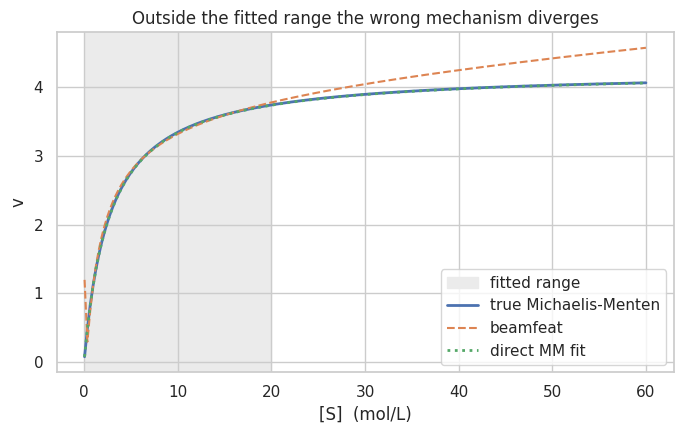

In [25]:
# Extrapolation is what separates them: predict beyond the fitted substrate range.
S_ext = np.linspace(0.05, 60, 200)
E_ext = np.full_like(S_ext, 1.25)
X_ext = pd.DataFrame({"S": S_ext, "E": E_ext, "decoy": np.full_like(S_ext, 3.0)})

v_true = V_MAX * E_ext * S_ext / (K_M + S_ext)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axvspan(0.05, 20, color="0.92", zorder=0, label="fitted range")
ax.plot(S_ext, v_true, label="true Michaelis-Menten", lw=2)
ax.plot(S_ext, model_mm.predict(X_ext), "--", label="beamfeat")
ax.plot(S_ext, michaelis_menten(np.vstack([S_ext, E_ext]), vmax_hat, km_hat),
        ":", lw=2, label="direct MM fit")
ax.set_xlabel("[S]  (mol/L)"); ax.set_ylabel("v")
ax.set_title("Outside the fitted range the wrong mechanism diverges")
ax.legend(); plt.tight_layout(); plt.show()


Inside the grey band all three curves agree. Outside it, the recovered formula parts company
with the truth — the true rate saturates at $V_{\max}[E]$, while the surrogate keeps climbing.

Practical guidance for kinetics:

- Treat a recovered formula as a **hypothesis**, and test it at concentrations outside the
  range you fitted.
- If you suspect saturation, fit Michaelis–Menten directly and compare.
- The `q_value` licenses the claim *"this feature is associated with the rate"*. Nothing more.


---
## 10. Optional: live data from SABIO-RK

The only networked cell. SABIO-RK is a curated database of biochemical reaction kinetics with a
REST API; non-commercial use is free. **If you are offline the cell prints a message and the
notebook continues** — nothing above depends on it.


In [26]:
import requests

ENTRY_URL = "https://sabiork.h-its.org/sabioRestWebServices/searchKineticLaws/entryIDs"
PARAM_URL = "https://sabiork.h-its.org/entry/exportToExcelCustomizable"


def fetch_sabio(ec="1.1.1.1", organism="Homo sapiens", limit=200, timeout=30):
    # Two-step API: search for entry IDs, then export parameters for those IDs.
    query = f'ECNumber:"{ec}" AND Organism:"{organism}"'
    resp = requests.get(ENTRY_URL, params={"format": "txt", "q": query}, timeout=timeout)
    resp.raise_for_status()

    ids = [x for x in resp.text.strip().split("\n") if x.strip().isdigit()][:limit]
    if not ids:
        return None

    fields = ["EntryID", "Substrate", "Organism", "ECNumber",
              "Parameter", "Temperature", "pH"]
    resp2 = requests.post(PARAM_URL,
                          params={"format": "tsv", "fields[]": fields},
                          data={"entryIDs[]": ids}, timeout=timeout)
    resp2.raise_for_status()
    return pd.read_csv(io.StringIO(resp2.text), sep="\t")


try:
    sabio = fetch_sabio()
    if sabio is None or sabio.empty:
        print("SABIO-RK returned no rows for this query — try another EC number.")
    else:
        print(f"SABIO-RK: {len(sabio)} parameter rows")
        display(sabio.head(10))
except Exception as exc:
    sabio = None
    print(f"[skipped] SABIO-RK unreachable ({type(exc).__name__}). Parts 1-9 are unaffected.")


[skipped] SABIO-RK unreachable (HTTPError). Parts 1-9 are unaffected.


SABIO-RK returns *fitted parameters* (Km, kcat) rather than raw progress curves, so it suits a
different question: **what does Km depend on** — temperature, pH, organism? To use it here,
pivot so each row is one measurement, put Km in the target, and put temperature and pH in `X`.

For raw progress curves you want a source with concentration-versus-time traces, processed as
in Part 7.


---
## Summary

| Part | Result |
|---|---|
| 2 | `r = k[H][O₂]` recovered exactly; k within 0.3% of GRI-Mech |
| 3 | Wrong units → the key reactant is dropped **silently**, wrong mechanism returned |
| 4 | Distractor species screened out; per-candidate q-values available |
| 5 | `r = k[OH]²` recovered; k within 0.4% |
| 6 | Rate law survives noise far beyond realistic experimental levels |
| 7 | Rate estimation dominates: careful initial rates → k exact; crude → mechanism wrong |
| 8 | Arrhenius needs linearisation; collinear terms bias Ea |
| 9 | Michaelis–Menten: excellent fit, **wrong mechanism**, diverges on extrapolation |

### Checklist for your own kinetics data

1. **Rates, not just concentrations.** Differentiate carefully (Part 7) or use integral methods.
2. **Independent observations.** One row per experiment; never all points along one trajectory.
3. **Rescale inputs** to roughly 0.01–100 and check variances before fitting (Part 3).
4. **Vary concentrations independently** — vary total pressure or initial ratios, not just one dial.
5. **Isothermal batches.** Handle temperature separately with an Arrhenius plot (Part 8).
6. **Declare units.** Dimensional analysis removes most of the nonsense for free.
7. **Test the recovered law outside the fitted range** before believing the mechanism (Part 9).

`beamfeat`: https://github.com/LD-Shell/beamFeat  ·  GRI-Mech 3.0 via Cantera  ·
SABIO-RK: https://sabiork.h-its.org


---
## Appendix — package issues surfaced by this notebook

Found against `beamfeat 0.1.1`. Neither affects the results above once worked around, but both
are worth reporting.

**A. The constant-column check uses an absolute variance floor.**
`Evaluator(variance_tol=1e-10)` compares raw variance, so physically meaningful columns are
rejected for being small in the chosen unit. When *every* column falls below the floor you get
`ValueError: no input column survived evaluation`. When only *some* do — the common case in
kinetics, where trace radicals and bulk species differ by orders of magnitude — the fit
succeeds silently with the important column missing (Part 3). A scale-free criterion, such as
the coefficient of variation, would be robust to the user's choice of unit.

**B. `equation()` drops terms whose coefficient rounds to zero at four decimals.**
The model and `predict()` are correct; only the printed string is wrong, and wrong by omission
rather than by rounding. Since a readable equation is the headline output, this matters more
than its size suggests. Significant figures or scientific notation would fix it.


In [27]:
# Minimal reproducer for issue B
rng = np.random.default_rng(0)
T_demo = rng.uniform(1000, 2000, 300)
y_demo = 3e-7 * T_demo ** 4 + 5000 + rng.normal(0, 1e4, 300)
X_demo = pd.DataFrame({"T": T_demo})

m_demo = BeamFeatRegressor(random_state=0).fit(X_demo, y_demo)

print("true relationship :  y = 3.0e-07 * T^4 + 5000")
print("selected feature  :", m_demo.formulas())
print("unscaled coef     :", m_demo.coef_ / m_demo.scaler_.scale_, "  <- correct")
print(f"R^2               : {m_demo.score(X_demo, y_demo):.5f}  <- model is fine")
print("equation()        :", m_demo.equation(), "  <- term silently missing")


true relationship :  y = 3.0e-07 * T^4 + 5000
selected feature  : ['((T)^2)^2']
unscaled coef     : [2.98930509e-07]   <- correct
R^2               : 0.99994  <- model is fine
equation()        : y = 12395.7748   <- term silently missing
